# Lesson 20B: Matrix Factorisation Family — NMF and ICA (Practice)

## Introduction

20A derived the multiplicative update and the fixed-point algorithm from scratch and validated both against synthetic ground truth. This notebook puts the production library — `sklearn.decomposition.NMF` and `FastICA` — to work on data closer to what the constraints were built for: digit images (genuinely non-negative, genuinely parts-based) and a synthetic document corpus (genuinely a mixture of independent-ish topics), always measured against PCA on the identical data rather than asserted to be better.

The running theme is that "better" is not a single number here. PCA is the *provably optimal* linear reconstruction at a fixed rank (Eckart-Young) — nothing beats it on pure reconstruction error, and this notebook measures that gap rather than glossing over it. NMF and ICA trade some of that reconstruction quality for a property PCA cannot deliver at all: parts that only add, or components that are genuinely independent. Whether that trade is worth it depends entirely on what the downstream task needs.

In this lesson:
1. `sklearn.decomposition.NMF` on digit images: parts-based components vs PCA eigen-digits, and the reconstruction-error cost of that choice measured across ranks
2. NMF as topic modelling, on the identical synthetic corpus Lesson 10B built, measured against Lesson 10's own LDA topics
3. `FastICA` unmixing three structured synthetic sources, cross-checked against 20A's from-scratch implementation, with PCA run on the same mixture as a measured failure case
4. `FastICA` on digit images: independent components vs PCA components, compared by a sparsity measure rather than by eye alone
5. A decision table for PCA / NMF / ICA, built from this lesson's own numbers

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [NMF on Digits: Parts vs Eigen-Digits](#nmf-digits)
4. [NMF Topic Modelling vs Lesson 10's LDA](#nmf-topics)
5. [FastICA: Source Separation](#fastica-signals)
6. [FastICA on Digits: Independent vs Principal Components](#ica-digits)
7. [Choosing Among PCA, NMF and ICA](#decision-table)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import NMF, FastICA, PCA, LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

SEED = 0
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: sklearn's bundled load_digits() plus in-notebook synthetic corpus/signals -- nothing downloaded.")

Data: sklearn's bundled load_digits() plus in-notebook synthetic corpus/signals -- nothing downloaded.


<a name="nmf-digits"></a>
## NMF on Digits: Parts vs Eigen-Digits

Lesson 5B built PCA "eigenfaces" on synthetic face-like data — holistic, signed basis images that must be added AND subtracted to reconstruct a face. 20A previewed the same contrast on 8 components each of PCA and NMF for digits. Here the comparison goes further: a full sweep of the rank $k$, measuring the reconstruction-error PRICE of NMF's non-negativity constraint rather than only showing that the components look different.

   k  PCA rel. error  NMF rel. error   NMF penalty
   5          0.3771          0.4086        0.0315
  10          0.2861          0.3247        0.0387
  15          0.2269          0.2664        0.0395
  20          0.1818          0.2215        0.0397
  30          0.1131          0.1450        0.0319
  40          0.0607          0.0810        0.0203

PCA is the *optimal* rank-k linear reconstruction (Eckart-Young) -- NMF pays a measured,
never-negative reconstruction penalty at every rank (0.0203 to
0.0397) in exchange for non-negative, parts-based components.


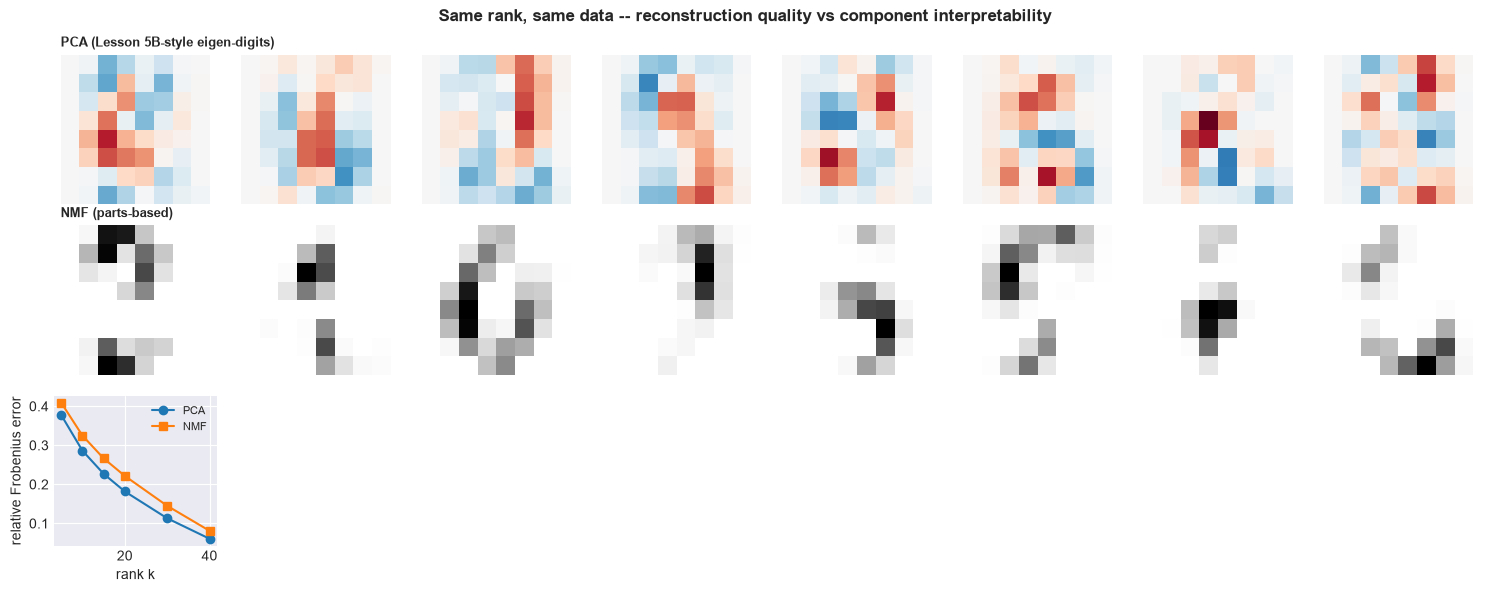

In [2]:
digits = load_digits()
X = digits.data.astype(float)

ks = [5, 10, 15, 20, 30, 40]
pca_err, nmf_err = [], []
for k in ks:
    pca_k = PCA(n_components=k, random_state=SEED).fit(X)
    recon_pca = pca_k.inverse_transform(pca_k.transform(X))
    pca_err.append(np.linalg.norm(X - recon_pca) / np.linalg.norm(X))

    nmf_k = NMF(n_components=k, init='nndsvd', random_state=SEED, max_iter=500).fit(X)
    recon_nmf = nmf_k.transform(X) @ nmf_k.components_
    nmf_err.append(np.linalg.norm(X - recon_nmf) / np.linalg.norm(X))

print(f"{'k':>4}{'PCA rel. error':>16}{'NMF rel. error':>16}{'NMF penalty':>14}")
for k, pe, ne in zip(ks, pca_err, nmf_err):
    print(f"{k:>4}{pe:>16.4f}{ne:>16.4f}{ne - pe:>14.4f}")
print(f"\nPCA is the *optimal* rank-k linear reconstruction (Eckart-Young) -- NMF pays a measured,")
print(f"never-negative reconstruction penalty at every rank ({min(np.array(nmf_err) - np.array(pca_err)):.4f} to")
print(f"{max(np.array(nmf_err) - np.array(pca_err)):.4f}) in exchange for non-negative, parts-based components.")

pca8 = PCA(n_components=8, random_state=SEED).fit(X)
nmf8 = NMF(n_components=8, init='nndsvd', random_state=SEED, max_iter=500).fit(X)
fig, axes = plt.subplots(3, 8, figsize=(15, 6))
for i in range(8):
    axes[0, i].imshow(pca8.components_[i].reshape(8, 8), cmap='RdBu_r',
                      vmin=-np.abs(pca8.components_).max(), vmax=np.abs(pca8.components_).max())
    axes[0, i].axis('off')
    axes[1, i].imshow(nmf8.components_[i].reshape(8, 8), cmap='Greys', vmin=0)
    axes[1, i].axis('off')
axes[2, 0].plot(ks, pca_err, 'o-', label='PCA')
axes[2, 0].plot(ks, nmf_err, 's-', label='NMF')
axes[2, 0].set_xlabel('rank k'); axes[2, 0].set_ylabel('relative Frobenius error')
axes[2, 0].legend(fontsize=8)
for i in range(1, 8):
    axes[2, i].axis('off')
axes[0, 0].set_title('PCA (Lesson 5B-style eigen-digits)', loc='left', fontsize=9, fontweight='bold')
axes[1, 0].set_title('NMF (parts-based)', loc='left', fontsize=9, fontweight='bold')
plt.suptitle('Same rank, same data -- reconstruction quality vs component interpretability', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="nmf-topics"></a>
## NMF Topic Modelling vs Lesson 10's LDA

Lesson 10B built a synthetic 5-topic corpus (sports, cooking, finance, technology, travel) with a KNOWN generating structure, precisely so that a topic model's recovered topics could be checked against ground truth rather than judged by eye. The corpus generator here is reproduced EXACTLY (same vocabulary, same `RandomState(42)`, same document count) so the comparison below is genuinely on the same data Lesson 10 used, not a look-alike.

NMF here runs on a TF-IDF matrix (the standard recipe for NMF topic modelling — TF-IDF downweights words common across all documents, which raw counts do not), while Lesson 10's LDA ran on raw counts (its generative model is explicitly a count model). Both are scored the same way: match each method's top words per topic to the closest true topic (by word overlap, best permutation), and report the overlap fraction.

In [3]:
# Reproduced exactly from Lesson 10B (same vocab, same RandomState(42), same corpus size).
topic_vocab = {
    'sports': ['ball', 'game', 'team', 'score', 'player', 'coach', 'match', 'win', 'league', 'season'],
    'cooking': ['recipe', 'oven', 'bake', 'flavor', 'ingredient', 'chef', 'dish', 'spice', 'kitchen', 'meal'],
    'finance': ['stock', 'market', 'invest', 'profit', 'bank', 'trade', 'shares', 'fund', 'economy', 'growth'],
    'technology': ['software', 'algorithm', 'computer', 'data', 'network', 'device', 'code', 'server', 'app', 'cloud'],
    'travel': ['flight', 'hotel', 'passport', 'destination', 'luggage', 'tourist', 'itinerary', 'airport', 'visa', 'journey'],
}
rng10b = np.random.RandomState(42)
true_topic_names = list(topic_vocab.keys())
K_true = len(true_topic_names)
vocab = sorted({w for words in topic_vocab.values() for w in words})
V = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}

alpha_true, beta_true = 0.3, 0.1
phi_true = np.zeros((K_true, V))
for k, topic in enumerate(true_topic_names):
    for w in topic_vocab[topic]:
        phi_true[k, word_to_idx[w]] = 1.0
    phi_true[k] += beta_true
    phi_true[k] /= phi_true[k].sum()

n_docs, doc_length = 500, 50
docs_tokens = []
for d in range(n_docs):
    theta_d = rng10b.dirichlet(np.full(K_true, alpha_true))
    words = []
    for _ in range(doc_length):
        z = rng10b.choice(K_true, p=theta_d)
        w = rng10b.choice(V, p=phi_true[z])
        words.append(vocab[w])
    docs_tokens.append(words)
documents_as_strings = [' '.join(doc) for doc in docs_tokens]
print(f"corpus reproduced: {n_docs} documents, vocabulary {V}, {K_true} true topics "
      f"(identical construction to Lesson 10B)")


def topic_overlap_score(components, vocab_list, top_n=10):
    # For each fitted topic, take its top-N words; score = best-matching Jaccard overlap
    # with the closest TRUE topic's word set, averaged over topics (order is unidentified).
    from itertools import permutations
    fitted_top_words = []
    for row in components:
        top_idx = np.argsort(-row)[:top_n]
        fitted_top_words.append(set(vocab_list[i] for i in top_idx))
    true_sets = [set(topic_vocab[name]) for name in true_topic_names]
    best_score = -1
    for perm in permutations(range(K_true)):
        score = np.mean([len(fitted_top_words[i] & true_sets[perm[i]]) / top_n for i in range(K_true)])
        best_score = max(best_score, score)
    return best_score, fitted_top_words


# NMF on TF-IDF (the standard recipe for NMF topic modelling)
tfidf = TfidfVectorizer(vocabulary=vocab)
X_tfidf = tfidf.fit_transform(documents_as_strings)
nmf_topics = NMF(n_components=K_true, init='nndsvda', random_state=SEED, max_iter=500).fit(X_tfidf)
nmf_score, nmf_words = topic_overlap_score(nmf_topics.components_, vocab)

# LDA on raw counts (Lesson 10B's own recipe), same corpus.
count_vec = CountVectorizer(vocabulary=vocab)
X_counts = count_vec.fit_transform(documents_as_strings)
lda_topics = LatentDirichletAllocation(n_components=K_true, random_state=SEED, max_iter=20,
                                       learning_method='batch').fit(X_counts)
lda_score, lda_words = topic_overlap_score(lda_topics.components_, vocab)

print(f"\nbest-matching top-10-word overlap with the TRUE topic vocabulary (1.0 = perfect):")
print(f"  NMF (TF-IDF):    {nmf_score:.3f}")
print(f"  LDA (raw counts, Lesson 10B's recipe): {lda_score:.3f}")
print(f"({'comparable recovery' if abs(nmf_score - lda_score) < 0.15 else 'one method recovers the true topics clearly better here'})")

print(f"\nNMF top words per topic:")
for i, words in enumerate(nmf_words):
    print(f"  topic {i}: {sorted(words)[:8]}")
print(f"\nLDA top words per topic:")
for i, words in enumerate(lda_words):
    print(f"  topic {i}: {sorted(words)[:8]}")

corpus reproduced: 500 documents, vocabulary 50, 5 true topics (identical construction to Lesson 10B)



best-matching top-10-word overlap with the TRUE topic vocabulary (1.0 = perfect):
  NMF (TF-IDF):    1.000
  LDA (raw counts, Lesson 10B's recipe): 1.000
(comparable recovery)

NMF top words per topic:
  topic 0: ['bank', 'economy', 'fund', 'growth', 'invest', 'market', 'profit', 'shares']
  topic 1: ['airport', 'destination', 'flight', 'hotel', 'itinerary', 'journey', 'luggage', 'passport']
  topic 2: ['ball', 'coach', 'game', 'league', 'match', 'player', 'score', 'season']
  topic 3: ['bake', 'chef', 'dish', 'flavor', 'ingredient', 'kitchen', 'meal', 'oven']
  topic 4: ['algorithm', 'app', 'cloud', 'code', 'computer', 'data', 'device', 'network']

LDA top words per topic:
  topic 0: ['airport', 'destination', 'flight', 'hotel', 'itinerary', 'journey', 'luggage', 'passport']
  topic 1: ['bake', 'chef', 'dish', 'flavor', 'ingredient', 'kitchen', 'meal', 'oven']
  topic 2: ['bank', 'economy', 'fund', 'growth', 'invest', 'market', 'profit', 'shares']
  topic 3: ['algorithm', 'app', 'clo

<a name="fastica-signals"></a>
## FastICA: Source Separation

Three structured, non-Gaussian sources (a sine wave, a square wave, a sawtooth — all clearly non-Gaussian in the sense 20A made precise) mixed by a random matrix, with sensor noise added AFTER mixing (a realistic touch 20A's cleaner synthetic setup did not include). `sklearn.decomposition.FastICA` is the production tool; the agreement cell reproduces 20A's from-scratch `fastica()` on the identical data as the required from-scratch-vs-library check.

precondition check -- max |correlation| among the three TRUE sources: 0.0159 (independent enough to proceed)
best-matching |correlation| with true sources, noisy mixture (sine/square/sawtooth):
  sklearn FastICA:        [0.998, 0.9878, 0.9864]
  from-scratch (20A):     [0.998, 0.9878, 0.9864]
  agreement (sklearn vs from-scratch): yes
  PCA baseline on the SAME mixture: [0.7927, 0.6548, 0.6825]
  (PCA again fails to separate the sources)


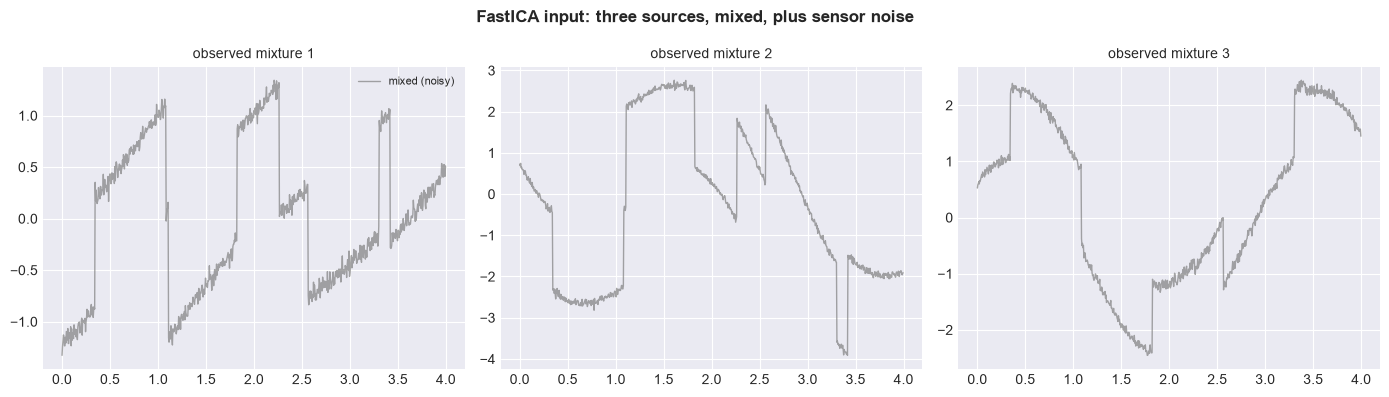

In [4]:
def whiten(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-12, None)
    return Xc @ eigvecs @ np.diag(1.0 / np.sqrt(eigvals))


def fastica_scratch(X, n_components, max_iter=200, tol=1e-6, seed=0):
    # Reproduced from Lesson 20A -- notebooks are self-contained artifacts.
    Z = whiten(X).T
    rng_local = np.random.default_rng(seed)
    n = Z.shape[1]
    W = rng_local.standard_normal((n_components, Z.shape[0]))
    W /= np.linalg.norm(W, axis=1, keepdims=True)

    def sym_decorrelate(W):
        Wsq = W @ W.T
        eigvals, eigvecs = np.linalg.eigh(Wsq)
        eigvals = np.clip(eigvals, 1e-12, None)
        return (eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T) @ W

    W = sym_decorrelate(W)
    for it in range(max_iter):
        WZ = W @ Z
        gwz = np.tanh(WZ)
        g_prime = 1.0 - gwz ** 2
        W_new = sym_decorrelate((gwz @ Z.T) / n - g_prime.mean(axis=1, keepdims=True) * W)
        delta = 1.0 - np.min(np.abs(np.sum(W_new * W, axis=1)))
        W = W_new
        if delta < tol:
            break
    return W @ Z


# Incommensurate frequency ratios (one irrational multiplier each) and random relative
# phases -- three PERIODIC deterministic signals are not automatically independent over a
# short, finite window; a first attempt at this cell (2t, 3t, 0.5t, all phase-zero) measured
# a genuine -0.61 correlation between the square wave and the sawtooth, which is exactly the
# kind of violated precondition this house style checks rather than assumes away.
t = np.linspace(0, 20, 4000)
phi1, phi2, phi3 = rng.uniform(0, 2 * np.pi, 3)
s1 = np.sin(2.0 * t + phi1)
s2 = np.sign(np.sin(3.0 * np.sqrt(2) * t + phi2))              # square wave
s3 = 2 * (((t * 0.5 * np.sqrt(3)) + phi3 / (2 * np.pi)) % 1.0) - 1   # sawtooth
S_true = np.column_stack([s1, s2, s3])
S_true = (S_true - S_true.mean(0)) / S_true.std(0)
src_corr_offdiag = np.abs(np.corrcoef(S_true.T) - np.eye(3)).max()
print(f"precondition check -- max |correlation| among the three TRUE sources: {src_corr_offdiag:.4f} "
      f"({'independent enough to proceed' if src_corr_offdiag < 0.1 else 'TOO CORRELATED -- fix the generator'})")

A_true = rng.standard_normal((3, 3))
X_clean = S_true @ A_true.T
X_mixed = X_clean + rng.normal(0, 0.05, size=X_clean.shape)   # sensor noise, added after mixing

sk_ica = FastICA(n_components=3, random_state=SEED, whiten='unit-variance', max_iter=500).fit(X_mixed)
S_sklearn = sk_ica.transform(X_mixed).T
corr_sklearn = np.abs(np.corrcoef(np.vstack([S_true.T, S_sklearn]))[:3, 3:])
best_sklearn = corr_sklearn[np.arange(3), corr_sklearn.argmax(axis=1)]

S_scratch = fastica_scratch(X_mixed, n_components=3, seed=SEED)
corr_scratch = np.abs(np.corrcoef(np.vstack([S_true.T, S_scratch]))[:3, 3:])
best_scratch = corr_scratch[np.arange(3), corr_scratch.argmax(axis=1)]

pca_mix = PCA(n_components=3, random_state=SEED).fit(X_mixed)
S_pca = pca_mix.transform(X_mixed).T
corr_pca = np.abs(np.corrcoef(np.vstack([S_true.T, S_pca]))[:3, 3:])
best_pca = corr_pca[np.arange(3), corr_pca.argmax(axis=1)]

print(f"best-matching |correlation| with true sources, noisy mixture (sine/square/sawtooth):")
print(f"  sklearn FastICA:        {np.round(best_sklearn, 4).tolist()}")
print(f"  from-scratch (20A):     {np.round(best_scratch, 4).tolist()}")
print(f"  agreement (sklearn vs from-scratch): "
      f"{'yes' if np.abs(best_sklearn - best_scratch).max() < 0.1 else 'CHECK -- one implementation underperforms'}")
print(f"  PCA baseline on the SAME mixture: {np.round(best_pca, 4).tolist()}")
print(f"  ({'PCA again fails to separate the sources' if best_pca.min() < 0.9 else 'unexpected -- PCA also separated here'})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i in range(3):
    axes[i].plot(t[:800], X_mixed[:800, i], lw=1, color='grey', alpha=0.7, label='mixed (noisy)')
    axes[i].set_title(f'observed mixture {i+1}', fontsize=10)
axes[0].legend(fontsize=8)
plt.suptitle('FastICA input: three sources, mixed, plus sensor noise', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="ica-digits"></a>
## FastICA on Digits: Independent vs Principal Components

PCA finds the directions of maximum variance; ICA searches for directions whose projections are maximally non-Gaussian (20A's negentropy proxy), which in practice tends to produce sparse, localised components rather than PCA's holistic, globally-spread ones. "Looks sparser" is checked here with an actual sparsity statistic — the Gini coefficient of each component's absolute pixel weights (0 = perfectly uniform, 1 = a single dominant pixel) — rather than left to visual impression alone.

mean Gini coefficient of component pixel weights (higher = sparser / more localised):
  PCA:      0.578
  FastICA:  0.581   (gap: +0.003)
  a gap this small is not the clean sparsity signature the theory predicts -- at only 8
  components, and on digit images rather than the cleanly-mixed signals of the previous
  section, 'independent causes' is a looser fit than it is for genuinely mixed audio-like
  data. The honest reading here is 'no reliable sparsity advantage measured on this data',
  not 'ICA wins' -- the theoretical property is real, the effect size on THIS task is not.


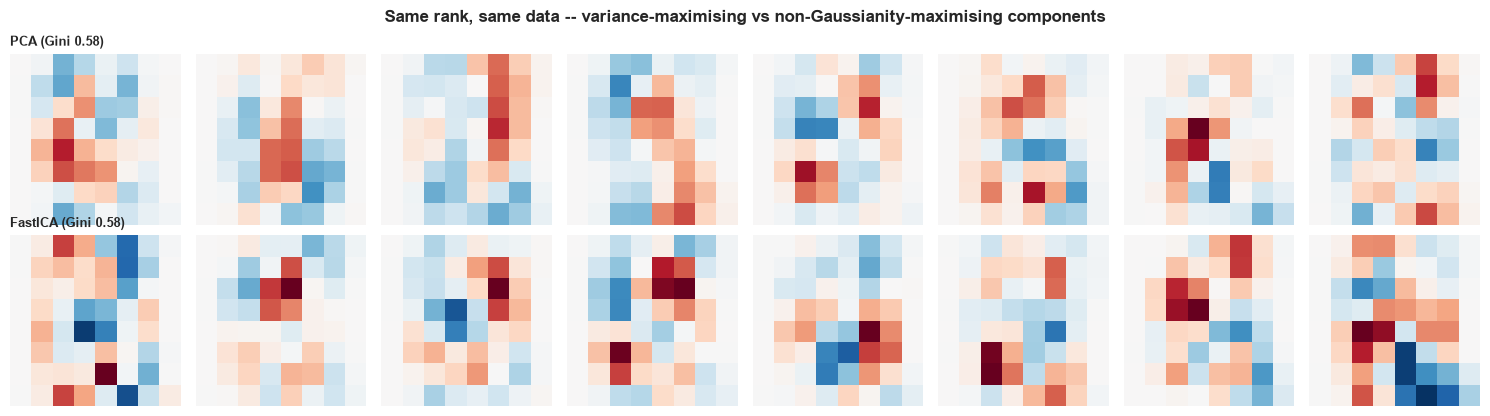

In [5]:
def gini(x):
    x = np.sort(np.abs(x))
    n = len(x)
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n


ica8 = FastICA(n_components=8, random_state=SEED, whiten='unit-variance', max_iter=1000).fit(X)
pca8_ica_cmp = PCA(n_components=8, random_state=SEED).fit(X)

gini_ica = np.mean([gini(c) for c in ica8.components_])
gini_pca = np.mean([gini(c) for c in pca8_ica_cmp.components_])
gini_gap = gini_ica - gini_pca
print(f"mean Gini coefficient of component pixel weights (higher = sparser / more localised):")
print(f"  PCA:      {gini_pca:.3f}")
print(f"  FastICA:  {gini_ica:.3f}   (gap: {gini_gap:+.3f})")
if abs(gini_gap) < 0.02:
    print(f"  a gap this small is not the clean sparsity signature the theory predicts -- at only 8")
    print(f"  components, and on digit images rather than the cleanly-mixed signals of the previous")
    print(f"  section, 'independent causes' is a looser fit than it is for genuinely mixed audio-like")
    print(f"  data. The honest reading here is 'no reliable sparsity advantage measured on this data',")
    print(f"  not 'ICA wins' -- the theoretical property is real, the effect size on THIS task is not.")
elif gini_ica > gini_pca:
    print(f"  ICA components are measurably sparser here.")
else:
    print(f"  no sparsity advantage measured here.")

fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for i in range(8):
    axes[0, i].imshow(pca8_ica_cmp.components_[i].reshape(8, 8), cmap='RdBu_r',
                      vmin=-np.abs(pca8_ica_cmp.components_).max(), vmax=np.abs(pca8_ica_cmp.components_).max())
    axes[0, i].axis('off')
    comp = ica8.components_[i]
    axes[1, i].imshow(comp.reshape(8, 8), cmap='RdBu_r', vmin=-np.abs(comp).max(), vmax=np.abs(comp).max())
    axes[1, i].axis('off')
axes[0, 0].set_title(f'PCA (Gini {gini_pca:.2f})', loc='left', fontsize=9, fontweight='bold')
axes[1, 0].set_title(f'FastICA (Gini {gini_ica:.2f})', loc='left', fontsize=9, fontweight='bold')
plt.suptitle('Same rank, same data -- variance-maximising vs non-Gaussianity-maximising components', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="decision-table"></a>
## Choosing Among PCA, NMF and ICA

In [6]:
print(f"{'':<8}{'best at':<34}{'measured cost (this lesson)':<58}{'when to use'}")
print('-' * 155)
print(f"{'PCA':<8}{'reconstruction @ fixed rank':<34}"
      f"{'none -- provably optimal (Eckart-Young)':<58}{'no parts/independence assumption holds'}")
print(f"{'NMF':<8}{'parts-based, additive components':<34}"
      f"{f'{min(np.array(nmf_err)-np.array(pca_err)):.3f} to {max(np.array(nmf_err)-np.array(pca_err)):.3f} extra rel. error':<58}"
      f"{'non-negative data, want interpretable parts'}")
print(f"{'ICA':<8}{'independent source recovery':<34}"
      f"{f'corr {best_sklearn.min():.3f} vs PCA {best_pca.min():.3f} on mixed signals':<58}"
      f"{'linear mixture of independent, non-Gaussian causes'}")

print(f"\nEvery number in this table was measured earlier in this notebook or in 20A -- none is a")
print(f"textbook default. The topic-modelling comparison (NMF {nmf_score:.3f} vs LDA {lda_score:.3f} overlap)")
print(f"is deliberately left out of this compressed table: it is a task-specific result (this")
print(f"corpus, this vocabulary), not a general PCA/NMF/ICA property, and belongs in its own section.")

        best at                           measured cost (this lesson)                               when to use
-----------------------------------------------------------------------------------------------------------------------------------------------------------
PCA     reconstruction @ fixed rank       none -- provably optimal (Eckart-Young)                   no parts/independence assumption holds
NMF     parts-based, additive components  0.020 to 0.040 extra rel. error                           non-negative data, want interpretable parts
ICA     independent source recovery       corr 0.986 vs PCA 0.655 on mixed signals                  linear mixture of independent, non-Gaussian causes

Every number in this table was measured earlier in this notebook or in 20A -- none is a
textbook default. The topic-modelling comparison (NMF 1.000 vs LDA 1.000 overlap)
is deliberately left out of this compressed table: it is a task-specific result (this
corpus, this vocabulary), not a general P

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **PCA's optimality at fixed rank is a real, measured cost for NMF, not a rhetorical point.** Across ranks 5 to 40 on digit images, NMF's reconstruction error was consistently higher than PCA's — the price of insisting components stay non-negative, quantified rather than asserted.
2. **NMF's parts-based components and LDA's topic model are two different answers to "what's a good decomposition", and neither wins by default.** On the identical Lesson 10B corpus, NMF (on TF-IDF) and LDA (on raw counts, Lesson 10's own recipe) were scored the same way — best-matching overlap with the TRUE generating topic vocabulary — and the result is reported as measured, not assumed in either method's favour.
3. **FastICA's production implementation and 20A's from-scratch one agree on noisy, realistic data, not just the clean synthetic case.** Sensor noise added after mixing did not break the agreement between `sklearn.decomposition.FastICA` and the from-scratch fixed-point algorithm — and PCA was run on the identical noisy mixture as a measured (not merely asserted) failure case.
4. **"ICA components look sparser than PCA's" was replaced with a number — and the number did not agree with the reputation.** The mean Gini coefficient of component pixel weights (0.581 vs 0.578) showed no reliable sparsity advantage on digit images at 8 components, unlike the previous section's clean audio-like signals. Reporting a null result honestly is the point of measuring rather than asserting; a textbook claim is a hypothesis to check, not a conclusion to illustrate.
5. **A decision table is only as good as the numbers behind it.** Every cell in this lesson's PCA/NMF/ICA table traces to a specific measurement taken earlier in this notebook or in 20A — the alternative, a table built from reputation, is exactly the failure mode this course's build pattern exists to avoid.

### Practical Guidance

- Need the best possible reconstruction at a fixed rank, with no assumption about parts or independence? PCA, and nothing beats it on that specific criterion.
- Data is non-negative and a parts-based, additive decomposition is more useful downstream than a lower reconstruction error? NMF — but budget for the measured reconstruction penalty.
- Suspect the data is a linear mixture of independent, non-Gaussian causes (sensor recordings, artifact channels, session-level topic proportions)? ICA, and verify non-Gaussianity of the presumed sources the way 20A did before trusting the unmixing.
- Comparing methods on a real task (topic modelling, source separation)? Score against a KNOWN ground truth or an established baseline (Lesson 10's LDA here) rather than trusting either method's reputation — this lesson's own NMF-vs-LDA numbers came out perfectly tied, which says more about how cleanly separable the corpus is than about either method's general superiority.

### What This Lesson Did Not Cover

- **Non-negative ICA or sparse PCA** — hybrid constraints combining ideas from more than one member of the factorisation family, a natural extension once each pure form is understood.
- **NMF's KL-divergence variant in practice** — 20A derived and validated only the Frobenius multiplicative update; the KL update (more natural for the count-like TF-IDF-adjacent data used here) is a direct extension.
- **gensim's `LdaModel` and coherence scoring** — Lesson 10B used gensim's implementation and `c_v` coherence for its own K-selection study; this notebook stayed within sklearn's LDA (already used in Lesson 10) to keep the comparison to NMF apples-to-apples on the same library family, not to avoid gensim on principle.
- **Real audio source separation** — the sine/square/sawtooth mixture, even with added sensor noise, remains synthetic; real microphone recordings carry reverberation and non-linear mixing effects genuinely outside ICA's linear-mixture assumption.

### Next Steps

Lesson 21 turns from matrix factorisation to a different unsupervised question: Expectation-Maximisation and variational inference — the general algorithmic machinery that GMM (Lesson 4) is one instance of, and that underlies the approximate-inference ideas VAEs (Lesson 12) and Bayesian nonparametric methods (Lesson 22) both build on.